In [1]:
import pandas as pd
import os
import sys

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.append(parent_dir)

from visual_genome.local import VisualGenome
from cross_validation import cross_validate
from metrics import results_to_mean_confidence_interval
from transformations import get_transforms

C:\Users\karab\AppData\Local\Temp\ipykernel_12476\43493845.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [5]:
IMAGES = "images.txt" # sample
FEATURES = "../experiment/data/vis/vis_features.csv" # all features
# FEATURES = "RSIVL_features.csv"
COLUMNS = ["image_id", "# of objects", "# of SAM segmentations", "# of FC-CLIP classes", "avg_region_similarity", "avg_rel_similarity", "predicted_complexity", "normalized_rating", "average autoregressive surprisal", "# of unique objects (synsets)", "VG_number_of_unique_nouns", "VG_number_of_unique_words", "DenseCap_number_of_unique_words", "DenseCap_number_of_unique_nouns"]
# COLUMNS = ["image_id", "# of SAM segmentations",  "# of FC-CLIP classes", "avg_region_similarity", "predicted_complexity", "complexity", "number_of_unique_words","number_of_unique_nouns"]

In [ ]:
# there should be a file called "images.txt"
with open(IMAGES, "r") as f:
    image_ids = [int(line) for line in f]
with open(FEATURES, "r") as f:
    features = pd.read_csv(f)
 
features = features[COLUMNS]                                # get only the columns we need
features = features[features["image_id"].isin(image_ids)]   # get only the rows we need

# change name
features = features.rename(columns={"# of SAM segmentations": "num_seg_64points", "# of FC-CLIP classes": "num_classes", "# of objects": "num_objects", "average autoregressive surprisal": "surprisal", "# of unique objects (synsets)": "no_of_unique_objects"})
features

### Cross Validated Linear Regression

In [13]:
model_strs = [
    "sqrt_seg_64points",
    "sqrt_num_classes",
    "sqrt_seg_64points + sqrt_num_classes",
    "sqrt_seg_64points_x_sqrt_num_classes",
    "sqrt_seg_64points_x_sqrt_num_classes + sqrt_seg_64points + sqrt_num_classes",
    "avg_region_similarity",
    "avg_rel_similarity",
    "avg_region_similarity + avg_rel_similarity",
    "sqrt_seg_64points + avg_region_similarity",
    "sqrt_seg_64points + avg_rel_similarity",
    "sqrt_num_classes + avg_region_similarity",
    "sqrt_num_classes + avg_rel_similarity",
    "sqrt_seg_64points + sqrt_num_classes + avg_region_similarity",
    "sqrt_seg_64points + sqrt_num_classes + avg_rel_similarity",
    "sqrt_seg_64points + sqrt_num_classes + avg_region_similarity + avg_rel_similarity",
    "surprisal",
    "surprisal + avg_region_similarity",
    "surprisal + avg_rel_similarity",
    "surprisal + avg_region_similarity + avg_rel_similarity",
    "no_of_unique_objects",
    "VG_number_of_unique_nouns",
    "VG_number_of_unique_words",
    "DenseCap_number_of_unique_words",
    "DenseCap_number_of_unique_nouns",
    "VG_number_of_unique_nouns + VG_number_of_unique_words",
    "VG_number_of_unique_nouns + DenseCap_number_of_unique_words",
    "VG_number_of_unique_nouns + DenseCap_number_of_unique_nouns",
    "VG_number_of_unique_words + DenseCap_number_of_unique_words",
    "VG_number_of_unique_words + DenseCap_number_of_unique_nouns",
    "DenseCap_number_of_unique_words + DenseCap_number_of_unique_nouns",
    "VG_number_of_unique_nouns + VG_number_of_unique_words + DenseCap_number_of_unique_words",
    "VG_number_of_unique_nouns + VG_number_of_unique_words + DenseCap_number_of_unique_nouns",
    "VG_number_of_unique_nouns + DenseCap_number_of_unique_words + DenseCap_number_of_unique_nouns",
    "VG_number_of_unique_words + DenseCap_number_of_unique_words + DenseCap_number_of_unique_nouns",
    "VG_number_of_unique_nouns + VG_number_of_unique_words + DenseCap_number_of_unique_words + DenseCap_number_of_unique_nouns",
    "sqrt_seg_64points + sqrt_num_classes + surprisal",
    "sqrt_seg_64points + sqrt_num_classes + surprisal + avg_region_similarity",
    "sqrt_seg_64points + sqrt_num_classes + surprisal + avg_rel_similarity",
    "sqrt_seg_64points + sqrt_num_classes + surprisal + avg_region_similarity + avg_rel_similarity",
    "sqrt_seg_64points + sqrt_num_classes + VG_number_of_unique_nouns",
    "sqrt_seg_64points + sqrt_num_classes + VG_number_of_unique_words",
    "sqrt_seg_64points + sqrt_num_classes + DenseCap_number_of_unique_words",
    "sqrt_seg_64points + sqrt_num_classes + DenseCap_number_of_unique_nouns",
]

In [ ]:
dataset_result = {}

def run_regression(data, N, M, target, model_strs, return_preds):
    df = data.copy()
    get_transforms(df)
    return cross_validate(df, N=N, M=M, target=target, model_strs=model_strs, return_preds=return_preds)

dataset_result["vg"] = run_regression(features, N=3, M=1, target="normalized_rating", model_strs=model_strs, return_preds=True) # change to "predicted_complexity" in need

In [ ]:
results_stats = results_to_mean_confidence_interval(dataset_result)
print("Reporting Spearman correlations.")

# sort according to correlation first
mod_to_corr = {}

for dset, v in results_stats.items():
    print("\nDATASET: {}".format(dset))
    for mod, vv in v.items():
        for s, (m, i) in vv.items():
            if s == "spearman_test":
                mod_to_corr[mod] = m
                
for mod, corr in sorted(mod_to_corr.items(), key=lambda x: x[1], reverse=True):
    print("{}: {}".format(mod, corr))

### Previous Datasets

In [2]:
FEATURES = "features/VISC_features.csv"
with open(FEATURES, "r") as f:
    features = pd.read_csv(f)

M_ = {"features/RSIVL_features.csv": 20,
      "features/VISC_features.csv": 2,
      "features/IC9600_abstract_features.csv": 1,
      "features/IC9600_paintings_features.csv": 1,
      "features/IC9600_scenes_features.csv": 1,
      "features/SAVOIAS_Art_features.csv": 20,
      "features/SAVOIAS_Scenes_features.csv": 2,
      "features/SAVOIAS_Suprematism_features.csv": 2,
      "features/SAVOIAS_Interior_Design_features.csv": 2,    
      "features/sem_features.csv": 2,
      "features/vis_features.csv": 2}


# change name
features = features.rename(columns={"# of SAM segmentations": "num_seg_64points", "# of FC-CLIP classes": "num_classes", "normalized_rating": "complexity"})
features

,image_id,number_of_unique_words,number_of_unique_nouns,number_of_unique_verbs,number_of_unique_adjectives,number_of_unique_adverbs,number_of_unique_pronouns,number_of_unique_determiners,number_of_unique_conjunctions,number_of_unique_prepositions,complexity,category,avg_region_similarity,num_seg_64points,num_classes
0,sun_aiztxdurlviyfwxz.jpg,42,28,6,16,1,0,0,1,1,0.5250,test,0.395325,169,29
1,sun_bplgyeqclqlogugd.jpg,28,21,10,9,2,0,0,0,2,0.5440,test,0.417120,80,3
2,sun_acdlgczjpwkeuvgy.jpg,35,25,3,7,0,0,0,1,0,0.4992,test,0.461352,146,24
3,sun_bhicdswlyikaabeq.jpg,34,24,5,10,0,0,0,0,0,0.5270,test,0.426587,115,20
4,sun_bfqkksxqisfiefwe.jpg,32,25,1,10,0,0,0,0,1,0.5570,test,0.487820,90,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,sun_bqfkrpcpakhwiilp.jpg,44,28,6,15,0,1,0,0,1,0.6550,test,0.361621,101,6
796,sun_bwkvdeqiygcrqwxi.jpg,23,16,3,10,0,0,0,0,2,0.6200,test,0.418208,36,3
797,sun_boxfizxdmlaotdgc.jpg,20,11,9,9,2,0,0,0,0,0.4490,test,0.434903,15,3
798,sun_bkzcruvdqfrkgnuz.jpg,39,31,4,12,2,0,0,0,0,0.5180,test,0.397444,84,13


In [3]:
model_strs = ["sqrt_seg_64points",
    "sqrt_num_classes",
    "sqrt_seg_64points + sqrt_num_classes",
    "sqrt_seg_64points_x_sqrt_num_classes",
    "sqrt_seg_64points_x_sqrt_num_classes + sqrt_seg_64points + sqrt_num_classes",
    "avg_region_similarity",
    "sqrt_seg_64points + avg_region_similarity",
    "sqrt_num_classes + avg_region_similarity",
    "sqrt_seg_64points + sqrt_num_classes + avg_region_similarity",
    "number_of_unique_nouns",
    "number_of_unique_words",
    "number_of_unique_words + number_of_unique_nouns",
    "sqrt_seg_64points + sqrt_num_classes + number_of_unique_nouns",
    "sqrt_seg_64points + sqrt_num_classes + number_of_unique_words",
    "sqrt_seg_64points + sqrt_num_classes + number_of_unique_words + number_of_unique_nouns",
    "sqrt_seg_64points + sqrt_num_classes + avg_region_similarity + number_of_unique_nouns",
    "sqrt_seg_64points + sqrt_num_classes + avg_region_similarity + number_of_unique_words",
    "sqrt_seg_64points + sqrt_num_classes + avg_region_similarity + number_of_unique_words + number_of_unique_nouns",


    ]

In [8]:
dataset_result = {}

def run_regression(data, N, M, target, model_strs, return_preds):
    df = data.copy()
    get_transforms(df)
    return cross_validate(df, N=N, M=M, target=target, model_strs=model_strs, return_preds=return_preds)

dataset_result["vg"] = run_regression(features, N=3, M=M_[FEATURES], target="complexity", model_strs=model_strs, return_preds=True) # change to "predicted_complexity" in need

In [11]:
OUR_FEATURE = "sqrt_seg_64points + sqrt_num_classes"
predicted_comp = dataset_result["vg"][OUR_FEATURE]['predictions']
actual_comp = dict(zip(features['image_id'], features['complexity']))


Overpredicted (399 images):
Image ID | Mean Predicted | Actual | Deviation | Individual Predictions
--------------------------------------------------------------------------------
sun_bljymfxujgbxjuvx.jpg |        0.526 |  0.176 | +   0.350 | [0.5128120509591338, 0.5389644978349538]
sun_bgshkoltnrmilxns.jpg |        0.861 |  0.558 | +   0.303 | [0.8257415368246666, 0.8957384633644331]
sun_aizcycyyvgfcdnzp.jpg |        0.502 |  0.214 | +   0.288 | [0.5016174959686571, 0.5031926013164506]
sun_baztjayuqhvdcxph.jpg |        0.474 |  0.196 | +   0.278 | [0.47139503119385207, 0.4774019615850766]
sun_ahphmnxxnwuclnfb.jpg |        0.580 |  0.303 | +   0.277 | [0.5892252526063542, 0.5713150704548804]

Underpredicted (401 images):
Image ID | Mean Predicted | Actual | Deviation | Individual Predictions
--------------------------------------------------------------------------------
sun_aekkynucosyodgdj.jpg |        0.388 |  0.772 | -   0.383 | [0.3848933073238028, 0.39190545099882773]
sun_bevxn

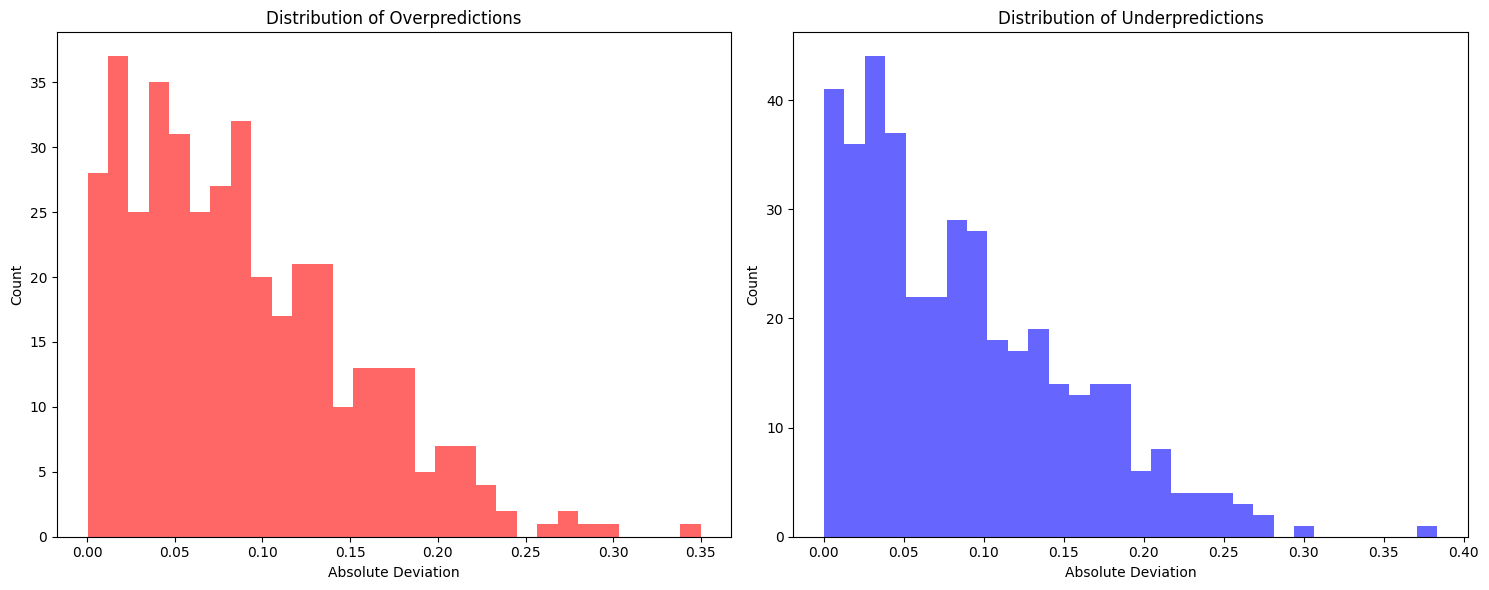

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate mean prediction for each image
mean_predictions = {img_id: np.mean(preds) for img_id, preds in predicted_comp.items()}

# Separate into overpredicted and underpredicted
overpredicted = {}
underpredicted = {}

for img_id in predicted_comp.keys():
    if img_id in actual_comp:
        mean_pred = mean_predictions[img_id]
        actual = actual_comp[img_id]
        deviation = mean_pred - actual_comp[img_id]  # Note: not using abs() here
        data = {
            'mean_predicted': mean_pred,
            'actual': actual,
            'deviation': abs(deviation),  # Store absolute deviation for sorting
            'raw_deviation': deviation,   # Store raw deviation for reference
            'predictions': predicted_comp[img_id]
        }
        
        if deviation > 0:  # We predicted higher complexity
            overpredicted[img_id] = data
        else:  # We predicted lower complexity
            underpredicted[img_id] = data

# Sort both dictionaries by absolute deviation
sorted_over = dict(sorted(overpredicted.items(), key=lambda x: x[1]['deviation'], reverse=True))
sorted_under = dict(sorted(underpredicted.items(), key=lambda x: x[1]['deviation'], reverse=True))

# Print results
print(f"\nOverpredicted ({len(overpredicted)} images):")
print("Image ID | Mean Predicted | Actual | Deviation | Individual Predictions")
print("-" * 80)
for i, (img_id, data) in enumerate(sorted_over.items()):
    if i >= 5:  # Show top 5
        break
    print(f"{img_id:<8} | {data['mean_predicted']:12.3f} | {data['actual']:6.3f} | +{data['deviation']:8.3f} | {data['predictions']}")

print(f"\nUnderpredicted ({len(underpredicted)} images):")
print("Image ID | Mean Predicted | Actual | Deviation | Individual Predictions")
print("-" * 80)
for i, (img_id, data) in enumerate(sorted_under.items()):
    if i >= 5:  # Show top 5
        break
    print(f"{img_id:<8} | {data['mean_predicted']:12.3f} | {data['actual']:6.3f} | -{data['deviation']:8.3f} | {data['predictions']}")

# Calculate statistics for both groups
over_deviations = [d['deviation'] for d in overpredicted.values()]
under_deviations = [d['deviation'] for d in underpredicted.values()]

print("\nStatistics:")
print(f"Overpredicted images: {len(overpredicted)} ({len(overpredicted)/(len(overpredicted)+len(underpredicted))*100:.1f}%)")
print(f"Mean deviation when overpredicting: {np.mean(over_deviations):.3f}")
print(f"Max deviation when overpredicting: {max(over_deviations):.3f}")
print(f"\nUnderpredicted images: {len(underpredicted)} ({len(underpredicted)/(len(overpredicted)+len(underpredicted))*100:.1f}%)")
print(f"Mean deviation when underpredicting: {np.mean(under_deviations):.3f}")
print(f"Max deviation when underpredicting: {max(under_deviations):.3f}")

# Create two histograms side by side
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.hist(over_deviations, bins=30, color='red', alpha=0.6)
plt.title('Distribution of Overpredictions')
plt.xlabel('Absolute Deviation')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(under_deviations, bins=30, color='blue', alpha=0.6)
plt.title('Distribution of Underpredictions')
plt.xlabel('Absolute Deviation')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [31]:
results_stats = results_to_mean_confidence_interval(dataset_result)
print("Reporting Spearman correlations.")

# sort according to correlation first
mod_to_corr = {}

for dset, v in results_stats.items():
    print("\nDATASET: {}".format(dset))
    for mod, vv in v.items():
        for s, (m, i) in vv.items():
            if s == "spearman_test":
                mod_to_corr[mod] = m
                
for mod, corr in sorted(mod_to_corr.items(), key=lambda x: x[1], reverse=True):
    print("{}: {}".format(mod, corr))

Reporting Spearman correlations.

DATASET: vg
sqrt_seg_64points + sqrt_num_classes + avg_region_similarity: 0.5714961042685207
sqrt_seg_64points + avg_region_similarity: 0.5700744469107827
sqrt_seg_64points + sqrt_num_classes + avg_region_similarity + number_of_unique_words: 0.5700238342553807
sqrt_seg_64points_x_sqrt_num_classes + sqrt_seg_64points + sqrt_num_classes: 0.569427726627456
sqrt_seg_64points + sqrt_num_classes + avg_region_similarity + number_of_unique_words + number_of_unique_nouns: 0.5688887300810751
sqrt_seg_64points + sqrt_num_classes + number_of_unique_words: 0.5687202818252045
sqrt_seg_64points + sqrt_num_classes + avg_region_similarity + number_of_unique_nouns: 0.5685058661485575
sqrt_seg_64points + sqrt_num_classes + number_of_unique_words + number_of_unique_nouns: 0.5676481381275053
sqrt_seg_64points: 0.5670570912429466
sqrt_seg_64points + sqrt_num_classes: 0.565569972782247
sqrt_seg_64points + sqrt_num_classes + number_of_unique_nouns: 0.5639982951524964
sqrt_seg